--- Starting Unified 2025 Analysis (Calibration & Reporting) ---
--- Period: 2025 (based on Tabela_consumo_medio_Itapua_12m.csv) ---
Total records loaded (consumers): 19,630
Total records loaded (consumption - 2025): 16,559

INNER JOIN: Filtering matriculas with valid consumption data
Matriculas loaded: 19,630
Matriculas loaded after remove duplicates: 19,263
Unique matriculas with  consumption in 2015: 16,559
Records after filter (only matriculas with valid consumption): 16,559
Records removed: 2,704



File saved in: ..\includes\Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2025_ajustado.csv
Records after merge with consumption data: 16,559

Step 1: Generating Profile Statistics Report (2025)
Profile Report saved: ..\resultados\medias_consumo_por_perfil_2025.csv

Profile Statistics (2025 - Filtered by valid consumption):
       PERFIL  MEDIA_CONSUMO_L_DIA  MEDIA_MORADORES  MEDIA_RENDA  QTD_RESIDENCIAS  PERCENTUAL_TOTAL
AMBIENTALISTA                41.39             3.34      2734.51             9250             55.86
     MODERADO               110.33             3.05      3246.91             1366              8.25
   PERDULARIO               303.48             2.51      3772.56             5943             35.89

VALIDATION REPORT: Consumption Data Coverage (2025)

Records by profile - Original dataset (after deduplication):
TP_COMPORTAMENTO
AMBIENTALISTA    10913
PERDULARIO        6832
MODERADO          1518
Name: count, dtype: int64

Records by profile - After filter


Calibration plot saved: ..\figuras\grafico_analise_parametros.pdf
------------------------------
Unified Process Complete.

SUMMARY - 2025 CALIBRATION
Total households with valid consumption in 2025: 16,559
Coverage rate: 85.96%
GAMA Sensitivity (k): 0.00029640
Base Intercept (b): 6.6889
Consumption ceiling (99th percentile): 626.8 L/person/day


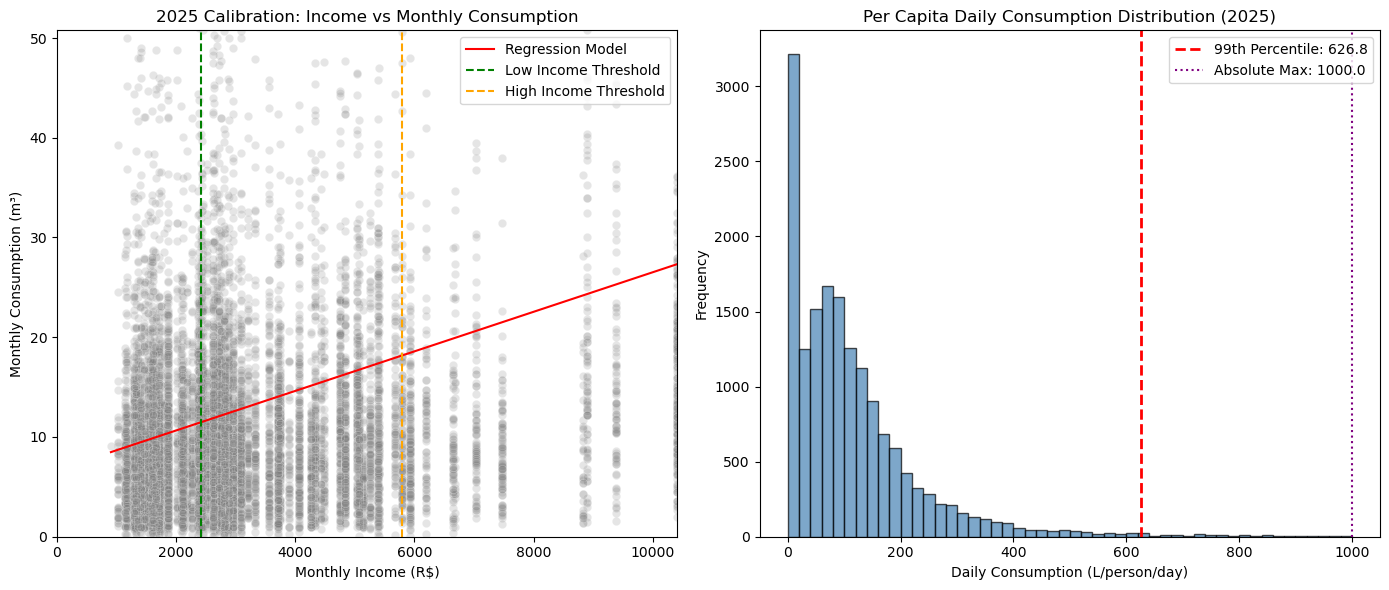

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. Configuration and Constants
# ==========================================
BASE_PATH = '..' 
INPUT_FILENAME = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda.csv'
CONSUMO_FILENAME = 'Tabela_consumo_medio_Itapua_2025_12m.csv'
OUTPUT_FILENAME = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2025_ajustado.csv'

# Column Mappings (Standardized from your Baseline file)
RENDA_COL = 'VL_RENDA_MEDIA_RESPONSAVEL'
CONSUMO_COL = 'NN_MEDIA_CONSUMO'
MORADORES_COL = 'NN_MORADORES_ANALISE'
DAILY_CONS_COL = 'NN_CONSUMO_DIARIO'
PROFILE_COL = 'TP_COMPORTAMENTO'

# Threshold Percentiles for Regression analysis
LOW_INCOME_PERCENTILE = 0.40
HIGH_INCOME_PERCENTILE = 0.90

# Percentile for maximum consumption limit (99th percentile)
MAX_CONSUMPTION_PERCENTILE = 0.99

def load_data(file_path):
    """Load consumer data from CSV file"""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return pd.read_csv(file_path, sep=';')

def load_consumo_data(file_path):
    """Load monthly consumption data from CSV file (2025 data)"""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    # Read with semicolon separator
    df = pd.read_csv(file_path, sep=';')
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    # Convert consumption to numeric
    if 'HCLQTCON' in df.columns:
        df['HCLQTCON'] = pd.to_numeric(df['HCLQTCON'], errors='coerce')
    return df

def main():
    print(f"--- Starting Unified 2025 Analysis (Calibration & Reporting) ---")
    print(f"--- Period: 2025 (based on Tabela_consumo_medio_Itapua_12m.csv) ---")

    # ==========================================
    # 2. Data Loading
    # ==========================================
    input_path = os.path.join(BASE_PATH, 'includes', INPUT_FILENAME)
    df = load_data(input_path)
    
    # Load consumption data (2025)
    consumo_path = os.path.join(BASE_PATH, 'includes', CONSUMO_FILENAME)
    df_consumo = load_consumo_data(consumo_path)
    
    # Ensure numeric types in consumer dataframe
    cols_to_fix = [RENDA_COL, CONSUMO_COL, MORADORES_COL, DAILY_CONS_COL]
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"Total records loaded (consumers): {len(df):,}")
    print(f"Total records loaded (consumption - 2025): {len(df_consumo):,}")

    # ==========================================
    # 3. INNER JOIN: Filter only matriculas with consumption data
    # ==========================================
    print("\n" + "="*60)
    print("INNER JOIN: Filtering matriculas with valid consumption data")
    print("="*60)
    
    # Convert SK_MATRICULA to string for proper merge
    df['SK_MATRICULA'] = df['SK_MATRICULA'].astype(str).str.strip()
    df_consumo['SK_MATRICULA'] = df_consumo['SK_MATRICULA'].astype(str).str.strip()
    
    # Get unique matriculas with  consumption filtering records strictly within the year 2025
    print(f"Matriculas loaded: {len(df):,}")
    df = df.drop_duplicates(subset=['SK_MATRICULA'], keep='first')
    print(f"Matriculas loaded after remove duplicates: {len(df):,}")
    
    matriculas_com_consumo = df_consumo['SK_MATRICULA'].unique()
    print(f"Unique matriculas with  consumption in 2015: {len(matriculas_com_consumo):,}")
    
        
    
    # Filter consumer dataframe to keep only matriculas with consumption data
    df_filtered = df[df['SK_MATRICULA'].isin(matriculas_com_consumo)].copy()
    print(f"Records after filter (only matriculas with valid consumption): {len(df_filtered):,}")
    print(f"Records removed: {len(df) - len(df_filtered):,}")
    
    #Save file for simulations ABM-WP
    output_path = os.path.join(BASE_PATH, 'includes', OUTPUT_FILENAME)
    df_filtered.to_csv(output_path, sep=';', index=False)
    print(f"\nFile saved in: {output_path}")
    
    # Optional: Merge consumption data to add HCLQTCON column to the filtered dataframe
    df_merged = pd.merge(df_filtered, df_consumo, on='SK_MATRICULA', how='inner')
    print(f"Records after merge with consumption data: {len(df_merged):,}")

    df_merged.rename(columns={'HCLQTCON_y':'HCLQTCON'}, inplace=True)
    # Check for any remaining NaN consumption values
    if df_merged['HCLQTCON'].isna().any():
        print(f"Warning: {df_merged['HCLQTCON'].isna().sum():,} records have NaN consumption after merge")
    
    # ==========================================
    # 4. PROFILE STATISTICS GENERATION (Using filtered data - 2025)
    # ==========================================
    print("\n" + "="*60)
    print("Step 1: Generating Profile Statistics Report (2025)")
    print("="*60)
    
    # Group by behavior and calculate requested metrics using filtered data
    df_stats = df_filtered.groupby(PROFILE_COL).agg({
        DAILY_CONS_COL: 'mean',
        MORADORES_COL: 'mean',
        RENDA_COL: 'mean',
        'SK_MATRICULA': 'count'
    }).reset_index()

    # Calculate percentages
    total_count = len(df_filtered)
    df_stats['PERCENTUAL_TOTAL'] = (df_stats['SK_MATRICULA'] / total_count) * 100

    # Rename and Format columns to match your required standard
    df_stats = df_stats.rename(columns={
        PROFILE_COL: 'PERFIL',
        DAILY_CONS_COL: 'MEDIA_CONSUMO_L_DIA',
        MORADORES_COL: 'MEDIA_MORADORES',
        RENDA_COL: 'MEDIA_RENDA',
        'SK_MATRICULA': 'QTD_RESIDENCIAS'
    })

    # Round values for the report
    for col in ['MEDIA_CONSUMO_L_DIA', 'MEDIA_MORADORES', 'MEDIA_RENDA', 'PERCENTUAL_TOTAL']:
        df_stats[col] = df_stats[col].round(2)

    # Export Report
    results_folder = os.path.join(BASE_PATH, 'resultados')
    os.makedirs(results_folder, exist_ok=True)
    stats_output_path = os.path.join(results_folder, 'medias_consumo_por_perfil_2025.csv')
    df_stats.to_csv(stats_output_path, sep=';', index=False)
    print(f"Profile Report saved: {stats_output_path}")
    print("\nProfile Statistics (2025 - Filtered by valid consumption):")
    print(df_stats.to_string(index=False))

    # ==========================================
    # 5. VALIDATION REPORT - Matriculas with/without consumption in 2025
    # ==========================================
    print("\n" + "="*60)
    print("VALIDATION REPORT: Consumption Data Coverage (2025)")
    print("="*60)
    
    # Count by profile for original and filtered data
    print("\nRecords by profile - Original dataset (after deduplication):")
    original_counts = df[PROFILE_COL].value_counts()
    print(original_counts)
    
    print("\nRecords by profile - After filter (only with consumption in 2025):")
    filtered_counts = df_filtered[PROFILE_COL].value_counts()
    print(filtered_counts)
    
    print("\nRecords lost by profile (no consumption data in 2025):")
    lost_counts = original_counts - filtered_counts
    print(lost_counts)
    
    print(f"\nTotal coverage: {len(df_filtered)/len(df)*100:.2f}% of records have valid consumption data in 2025")

    # ==========================================
    # 6. CALCULATE GLOBAL MAX CONSUMPTION LIMIT (using filtered data)
    # ==========================================
    print("\n" + "="*60)
    print("Step 2: Calculating Global Maximum Consumption Limit for GAMA")
    print("="*60)
    
    # Get per capita daily consumption data from filtered dataset
    per_capita_consumption = df_filtered[DAILY_CONS_COL].dropna()
    
    # Remove unrealistic outliers (values > 1000 L/person/day are likely data errors)
    per_capita_consumption = per_capita_consumption[per_capita_consumption <= 1000]
    
    # Calculate the maximum value (99th percentile to avoid outliers)
    max_consumption_absolute = per_capita_consumption.max()
    max_consumption_percentile_95 = per_capita_consumption.quantile(0.95)
    max_consumption_percentile_99 = per_capita_consumption.quantile(MAX_CONSUMPTION_PERCENTILE)
    
    print(f"\n--- Global Maximum Daily Consumption (L/person/day) ---")
    print(f"Absolute Maximum: {max_consumption_absolute:.1f}")
    print(f"95th Percentile: {max_consumption_percentile_95:.1f}")
    print(f"99th Percentile (RECOMMENDED): {max_consumption_percentile_99:.1f}")
    print(f"Total records considered: {len(per_capita_consumption):,}")
    
    # Save max consumption parameter
    df_max_consumption = pd.DataFrame({
        'parametro': [
            'teto_consumo_absoluto',
            'teto_consumo_percentil_95',
            'teto_consumo_percentil_99'
        ],
        'valor': [
            max_consumption_absolute,
            max_consumption_percentile_95,
            max_consumption_percentile_99
        ],
        'descricao': [
            'Valor máximo absoluto observado (pode conter outliers)',
            '95% dos consumidores estão abaixo deste valor',
            '99% dos consumidores estão abaixo deste valor (RECOMENDADO)'
        ]
    })
    
    max_cons_path = os.path.join(BASE_PATH, 'includes', 'parametros_teto_consumo_2025.csv')
    df_max_consumption.to_csv(max_cons_path, sep=';', index=False)
    print(f"\nMax consumption parameters saved: {max_cons_path}")

    # ==========================================
    # 7. CALIBRATION PARAMETERS (Regression using filtered data)
    # ==========================================
    print("\n" + "="*60)
    print("Step 3: Calculating Regression Parameters for GAMA")
    print("="*60)
    
    # Cleaning specifically for regression (removing 0s and NaNs)
    df_reg = df_filtered.dropna(subset=[RENDA_COL, CONSUMO_COL])
    df_reg = df_reg[(df_reg[RENDA_COL] > 0) & (df_reg[CONSUMO_COL] > 0)]

    low_income_limit = df_reg[RENDA_COL].quantile(LOW_INCOME_PERCENTILE)
    high_income_limit = df_reg[RENDA_COL].quantile(HIGH_INCOME_PERCENTILE)

    X = df_reg[[RENDA_COL]].values
    y = df_reg[CONSUMO_COL].values

    reg = LinearRegression()
    reg.fit(X, y)

    slope = reg.coef_[0]
    intercept = reg.intercept_

    # Normalized Factor for GAMA: Consumption = b * (1 + k * Income)
    normalized_sensitivity = slope / intercept if intercept > 0 else 0.0001

    print(f"GAMA Sensitivity (k): {normalized_sensitivity:.8f}")
    print(f"Base Intercept (b): {intercept:.4f}")
    print(f"Low Income Limit (40th percentile): R$ {low_income_limit:.2f}")
    print(f"High Income Limit (90th percentile): R$ {high_income_limit:.2f}")

    # ==========================================
    # 8. Export Parameters
    # ==========================================
    df_params = pd.DataFrame({
        'parametro': [
            'limite_baixa_renda', 
            'limite_alta_renda', 
            'sensibilidade_renda', 
            'intercepto_base',
            'teto_consumo_diario'
        ],
        'valor': [
            low_income_limit, 
            high_income_limit, 
            normalized_sensitivity, 
            intercept,
            max_consumption_percentile_99
        ]
    })
    params_path = os.path.join(BASE_PATH, 'includes', 'parametros_renda_calculados_2025.csv')
    df_params.to_csv(params_path, sep=';', index=False)
    print(f"\nIncome parameters saved: {params_path}")

    # ==========================================
    # 9. Visualization
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Income vs Consumption (using filtered data)
    ax1 = axes[0]
    sns.scatterplot(x=df_reg[RENDA_COL], y=df_reg[CONSUMO_COL], alpha=0.2, color='gray', ax=ax1)
    x_range = np.linspace(df_reg[RENDA_COL].min(), df_reg[RENDA_COL].max(), 100)
    ax1.plot(x_range, intercept + slope * x_range, color='red', label='Regression Model')
    ax1.axvline(low_income_limit, color='green', linestyle='--', label='Low Income Threshold')
    ax1.axvline(high_income_limit, color='orange', linestyle='--', label='High Income Threshold')
    ax1.set_title('2025 Calibration: Income vs Monthly Consumption')
    ax1.set_xlabel('Monthly Income (R$)')
    ax1.set_ylabel('Monthly Consumption (m³)')
    ax1.set_xlim(0, df_reg[RENDA_COL].quantile(0.98))
    ax1.set_ylim(0, df_reg[CONSUMO_COL].quantile(0.98))
    ax1.legend()
    
    # Plot 2: Per Capita Consumption Distribution with limit
    ax2 = axes[1]
    ax2.hist(per_capita_consumption, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax2.axvline(max_consumption_percentile_99, color='red', linestyle='--', linewidth=2,
                label=f'99th Percentile: {max_consumption_percentile_99:.1f}')
    ax2.axvline(max_consumption_absolute, color='purple', linestyle=':', linewidth=1.5,
                label=f'Absolute Max: {max_consumption_absolute:.1f}')
    ax2.set_xlabel('Daily Consumption (L/person/day)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Per Capita Daily Consumption Distribution (2025)')
    ax2.legend()
    
    fig_path = os.path.join(BASE_PATH, 'figuras', 'grafico_analise_parametros.pdf')
    os.makedirs(os.path.join(BASE_PATH, 'figuras'), exist_ok=True)
    plt.tight_layout()
    plt.savefig(fig_path, format='pdf', bbox_inches='tight',dpi=300)
    
    print(f"\nCalibration plot saved: {fig_path}")
    print("-" * 30)
    print("Unified Process Complete.")
    print("\n" + "=" * 50)
    print("SUMMARY - 2025 CALIBRATION")
    print("=" * 50)
    print(f"Total households with valid consumption in 2025: {len(df_filtered):,}")
    print(f"Coverage rate: {len(df_filtered)/len(df)*100:.2f}%")
    print(f"GAMA Sensitivity (k): {normalized_sensitivity:.8f}")
    print(f"Base Intercept (b): {intercept:.4f}")
    print(f"Consumption ceiling (99th percentile): {max_consumption_percentile_99:.1f} L/person/day")
    print("=" * 50)

if __name__ == "__main__":
    main()